Starting Monte Carlo simulation...
0.001% completed, estimated time remaining: 0h 4m 11.5s
0.010% completed, estimated time remaining: 0h 2m 29.0s
0.100% completed, estimated time remaining: 0h 2m 5.6s
1.000% completed, estimated time remaining: 0h 2m 9.6s
5.000% completed, estimated time remaining: 0h 1m 48.9s
10.000% completed, estimated time remaining: 0h 1m 35.4s
20.000% completed, estimated time remaining: 0h 1m 20.7s
50.000% completed, estimated time remaining: 0h 1m 5.9s
75.000% completed, estimated time remaining: 0h 0m 36.8s
90.000% completed, estimated time remaining: 0h 0m 15.3s
100.000% completed, estimated time remaining: 0h 0m 0.0s
State at t=0.2617993877991494 averaged over 100 trajectories
Trace of averaged state: 0.6343907773 (should be 1.0)
Simulation completed in 0h 2m 36.6s.
At time t = 65.449847, the mean number operator <n> = 0.48877935200078898025921603220922406762838363647461

Attempting mesolve...
ERROR: mesolve failed: RuntimeError: DISABLED: mesolve donesn't 

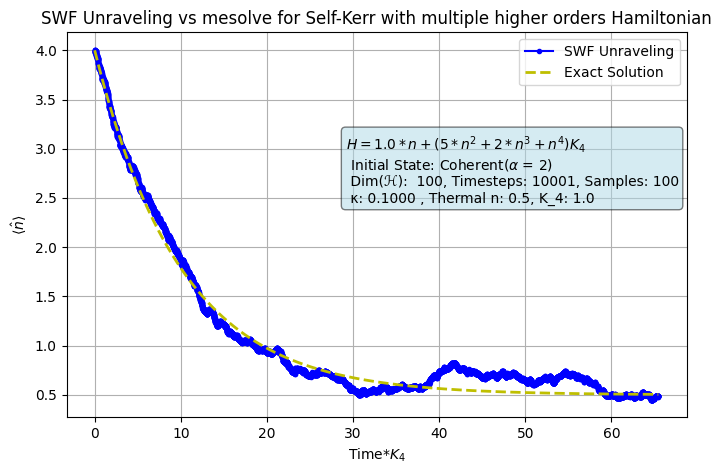

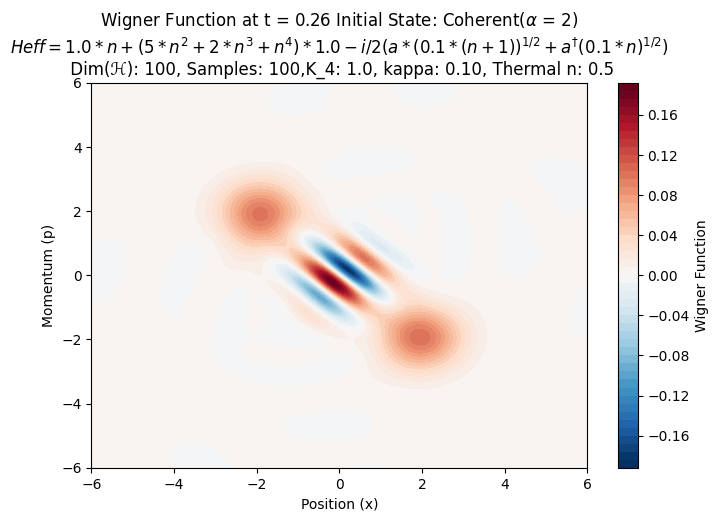

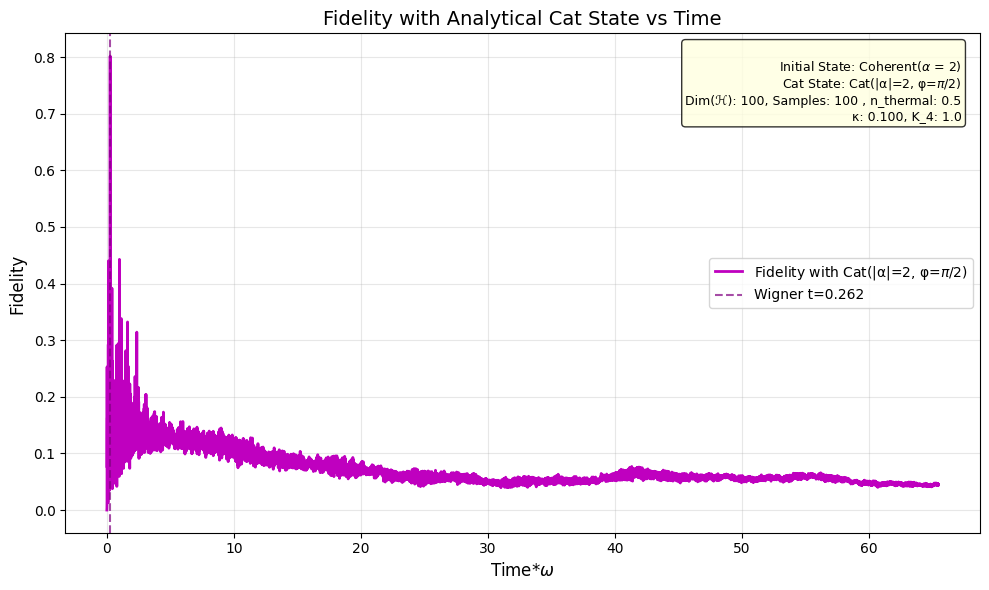

In [42]:
from matplotlib.pylab import norm
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt
import time  
import cmath 
from qutip import wigner
import matplotlib.colors as mcolors


def format_time(seconds): #Convert seconds to hours, minutes, seconds format.
    hours = int(seconds // 3600)
    minutes = int((seconds % 3600) // 60)
    secs = seconds % 60
    return f"{hours}h {minutes}m {secs:.1f}s"
# Function to define operators for dimension N (all are Qobj)
def define_operators(N):
    a = qt.destroy(N)          # Annihilation operator
    a_dag = qt.create(N)       # Creation operator (Hermitian conjugate of a)
    n = qt.num(N)              # Number operator n = a_dag * a
    x = qt.position(N)         # Position operator x = (a + a_dag) / sqrt(2)
    p = qt.momentum(N)         # Momentum operator p = -1j * (a - a_dag) / sqrt(2)
    return a, a_dag, n, x, p

def get_analytical_cat_state(t, N, Amplitude,omega, phase_cat):
    
    alpha_rotated = Amplitude * np.exp(-1j * omega*t)
    cat_unnorm = (qt.coherent(N, alpha_rotated) + 
                  np.exp(1j * phase_cat) * qt.coherent(N, -alpha_rotated))
    
    return cat_unnorm / cat_unnorm.norm()


# User input: Select Hilbert space dimension N
N = int(input("Enter the Hilbert space dimension N: "))

# Define operators based on N
a, a_dag, n, x, p = define_operators(N)

# Define Lindblad operators Ls
kappa = 0.1# Damping rate

n_thermal = 0.5  # Average thermal photon number in bath, gor 8Ghz at T=0,2K 
Ls = [ cmath.sqrt(kappa * (n_thermal + 1)) * a,   # Spontaneous + stimulated emission
       cmath.sqrt(kappa * n_thermal) * a_dag   ]   # Thermal absorption (gain) 


# Define Hamiltonian H

K_4 = 1.0 # Nonlinearity strength
omega = 1.0 # Detuning, set to 0 for simplicity, can be changed to see its effect on the cat state generation and fidelity
H = omega*n+(5*n**2 + 2*n**3 +  n**4 )*K_4 #dimensionless Hamiltonian
Heff = H - 1j/2 * sum(L.dag() * L for L in Ls)  # Effective non-Hermitian Hamiltonian for no-jump evolution

str_H = f"$H = {omega}*n+ (5*n^2 + 2*n^3 + n^4)K_4$"  # String representation of the Hamiltonian for results file
str_Heff = f"$Heff = {omega}*n+ (5*n^2 + 2*n^3 + n^4)*{K_4}-i/2(a*({kappa:.1f}*(n+1))^{{1/2}} +a^{{\\dagger}}({kappa:.1f}*n)^{{1/2}})$"  # String representation of the effective Hamiltonian for results file

# Define initial state psi0 and its string representation for results file
Amplitude = 2
#psi0 = qt.basis(N, Amplitude)  
#initial_state_str = f"Fock(n={int(Amplitude)})"
psi0 = qt.coherent(N, Amplitude)  # Coherent state with amplitude x
initial_state_str = f"Coherent($\\alpha$ = {Amplitude})"  


#Time list (Fewer timesteps can cause numerical instabilities)
timestep=1+10**4
final_time =500*np.pi/(4*3*2*K_4) 
tlist = np.linspace(0, final_time, timestep)  # Reduced for faster testing; increase for finer dt
dt_list = np.diff(tlist)  # Time steps

sample = 100 #<100 can cause instabilities

target_time = 2*np.pi /(4*3*2*K_4)  # Time to store the sate for Wigner function calculation
target_index = np.argmin(np.abs(tlist - target_time))
state_at_target_time = None # To initialize the storing state 

# Define cat state 
cat_state = get_analytical_cat_state(target_time, N, Amplitude, omega+2*K_4, np.pi/2) 
cat_state_str = f"Cat(|α|={Amplitude}, φ=$\\pi/2 $)"
fidelity_cat = np.zeros(len(tlist)) # stores fidelity of each trajectory with the cat state at each time step

mean_n = np.zeros(len(tlist), dtype=complex)
milestones = [0.001, 0.01, 0.1, 1, 5, 10, 20, 50, 75, 90, 100]
milestone_index = 0
start_time = time.time()
total_steps = sample * (len(tlist) - 1)
current_step = 0

dt = tlist[1] - tlist[0]
evol_op = (-1.0j*Heff*dt).expm()

print("Starting Monte Carlo simulation...")

for count in range(sample):
    psi = psi0
    n_expect_list = [qt.expect(n, psi)]
    
    for i in range(1, len(tlist)):
        #dt = dt_list[i-1]
        #t_current = tlist[i]
        u = np.random.random()


        dps = [np.real(dt * qt.expect(L.dag() * L, psi)) for L in Ls]
        dP = np.sum(dps)
        
        if dP < u:
            
            
            psi=evol_op*psi

            #Normalization
            norm_val = psi.norm()
            if norm_val > 0:
                psi = psi / norm_val
            else:
                print(f"Warning: Zero norm at step {i}, trajectory {count}")
                break
            
             # CHECK: State should be normalized (trace = 1 for pure state = |<psi|psi>|^2)
            trace_check = np.abs(psi.norm())**2
            if np.abs(trace_check - 1.0) > 1e-12:
                print(f"WARNING: Trace deviated at step {i}: {trace_check:.10f}")

        else:
            u_jump = np.random.random()
            Q = np.cumsum(dps) / dP
            k = np.searchsorted(Q, u_jump, side='left')
            psi = Ls[k] * psi
            
            norm_val = psi.norm()
            if norm_val > 0:
                psi = psi / norm_val
            
            # TRACE CHECK 2: After jump
            trace_check = np.abs(psi.norm())**2
            if np.abs(trace_check - 1.0) > 1e-12:
                print(f"WARNING: Trace after jump at step {i}: {trace_check:.10f}")
        
        n_expect_list.append(qt.expect(n, psi)) 

        if i == target_index:
            if count == 0:
                state_at_target_time = psi.copy()
            else:
                state_at_target_time += psi
                
        fidelity_this_traj  = qt.fidelity(psi, cat_state)**2

        if count == 0:
            fidelity_cat[i] = fidelity_this_traj
        else:
            fidelity_cat[i] += fidelity_this_traj
        
        current_step += 1
        progress = (current_step / total_steps) * 100
        if milestone_index < len(milestones) and progress >= milestones[milestone_index]:
            elapsed_time = time.time() - start_time
            estimated_total_time = elapsed_time / (progress / 100)
            remaining_time = estimated_total_time - elapsed_time
            print(f"{milestones[milestone_index]:.3f}% completed, estimated time remaining: {format_time(remaining_time)}")
            milestone_index += 1
    
    while len(n_expect_list) < len(tlist):
        n_expect_list.append(n_expect_list[-1])
    mean_n += np.array(n_expect_list)   

    # Average target state over all trajectories 
if state_at_target_time is not None:
    state_at_target_time /= sample
    print(f"State at t={target_time} averaged over {sample} trajectories")
    
if state_at_target_time.type == 'oper':
    # Mixed state (density matrix)
    trace = state_at_target_time.tr()  # Should be 1.0
    purity = (state_at_target_time ** 2).tr()  # Tr(ρ²), should be ≤ 1
    print(f"Trace of averaged state: {trace:.10f} (should be 1.0)")
    print(f"Purity of averaged state: {purity:.10f} (≤ 1, lower = more mixed)")
else:
    # Pure state (ket)
    trace = np.abs(state_at_target_time.norm())**2
    print(f"Trace of averaged state: {trace:.10f} (should be 1.0)")

mean_n /= sample

fidelity_cat /= sample # Average fidelity over all trajectories

total_time = time.time() - start_time
print(f"Simulation completed in {format_time(total_time)}.")
index = np.argmin(np.abs(tlist - final_time))
print(f"At time t = {tlist[index]:.6f}, the mean number operator <n> = {np.real(mean_n[index]):.50f}")

# Exact analytical solution: Lindblad adjoint equation solution
n0 = np.real(qt.expect(n, psi0))  # Initial photon number expectation value
n_exact = n_thermal + (n0 - n_thermal) * np.exp(-np.real(kappa) * tlist)

# Try Qutip's solvers
print("\nAttempting mesolve...")

try:
    raise RuntimeError("DISABLED: mesolve donesn't work for this nonlinear Hamiltonian, needs custom implementation. See code comments for details.")
    mesolve_start_time = time.time()
    result_mesolve = qt.mesolve(H, psi0, tlist, Ls, [n], options=qt.Options(store_states=True)) 
    mean_n_mesolve = result_mesolve.expect[0]
    mesolve_time = time.time() - mesolve_start_time
    print(f"qt.mesolve completed in {format_time(mesolve_time)}.")
    print(f"Full mesolve result info:\n{result_mesolve}")
    print(f"mesolve n at t={tlist[index]:.6f} is {mean_n_mesolve[index]:.50f}")
    mesolve_status = "success"
except Exception as e:
    print(f"ERROR: mesolve failed: {type(e).__name__}: {e}")
    mesolve_status = "failed"


print("\nAttempting mcsolve...")
try:
    raise RuntimeError("DISABLED: mcsolve donesn't work for this nonlinear Hamiltonian, needs custom implementation. See code comments for details.")
    mcsolve_start_time = time.time()
    result_mcsolve = qt.mcsolve(H, psi0, tlist, Ls, [n], ntraj=sample) 
    mean_n_mcsolve = result_mcsolve.expect[0]
    mcsolve_time = time.time() - mcsolve_start_time
    mcsolve_status = "success"
    print(f"qt.mcsolve completed in {format_time(mcsolve_time)}.")
    print(f"Full mcsolve result info:\n{result_mcsolve}")
    print(f"mcsolve n at t={tlist[index]:.6f} is {mean_n_mcsolve[index]:.50f}") 
except Exception as e:
    print(f"ERROR: mcsolve failed: {type(e).__name__}: {e}")
    mcsolve_status = "failed"


# RMSE between SWF and exact solution, might not be usefull since we dont know if mesolve is correct, but it can be a sanity check
rmse = np.sqrt(np.mean((np.real(mean_n) - n_exact)**2))
rmse_mesolve = np.sqrt(np.mean((mean_n_mesolve - n_exact)**2)) if mesolve_status == "success" else None
rmse_mcsolve = np.sqrt(np.mean((mean_n_mcsolve - n_exact)**2)) if mcsolve_status == "success" else None


# Plot 1: Unraveling vs. qt.mesolve vs. qt.mcsolve
plt.figure(figsize=(8, 5))
plt.plot(tlist, np.real(mean_n), '.-b', label="SWF Unraveling")
if mesolve_status == "success":
    plt.plot(tlist, mean_n_mesolve, '--r', label="mesolve")
if mcsolve_status == "success":
    plt.plot(tlist, mean_n_mcsolve, ':g', label="mcsolve")
plt.plot(tlist, n_exact, 'y--', linewidth=2, label="Exact Solution")
plt.xlabel(r'Time*$ K_4 $')
plt.ylabel(r'$\langle \hat{n} \rangle$')
plt.title(f'SWF Unraveling vs mesolve for Self-Kerr with multiple higher orders Hamiltonian')
plt.legend(loc='upper right')  # Position legend to avoid overlap
plt.grid(True)

# Add a parameter box 
param_text = f"{str_H}\n Initial State: {initial_state_str} \n Dim(ℋ):  {N}, Timesteps: {timestep}, Samples: {sample}\n κ: {kappa.real:.4f} , Thermal n: {n_thermal}, K_4: {K_4}"
plt.text(0.45, 0.55, param_text, transform=plt.gca().transAxes, fontsize=10,
         verticalalignment='bottom', bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.5))


# Plot 2:Wigner function for Manual MC
xvec = np.linspace(-6, 6, 200)
Pvec = np.linspace(-6, 6, 200)
W_manual = wigner(state_at_target_time, xvec, Pvec)

# TRACE CHECK 4: Verify Wigner function integrates to 1 

W_integral = np.trapezoid(np.trapezoid(W_manual, xvec), Pvec)
print(f"Wigner function integral: {W_integral:.6f} (should be ~1.0)")

W_min, W_max = W_manual.min(), W_manual.max()
norm = mcolors.TwoSlopeNorm(vmin=W_min, vcenter=0, vmax=W_max)

plt.figure(figsize=(8, 5))
plt.contourf(xvec, Pvec, W_manual, levels=50, cmap='RdBu_r', norm=norm)
plt.colorbar(label='Wigner Function')
plt.xlabel('Position (x)')
plt.ylabel('Momentum (p)')
plt.title(f'Wigner Function at t = {target_time:.2f} Initial State: {initial_state_str} \n{str_Heff}\n Dim(ℋ): {N}, Samples: {sample},K_4: {K_4}, kappa: {kappa.real:.2f}, Thermal n: {n_thermal}')

# PLOT 3: Fidelity with analytical cat state over time
plt.figure(figsize=(10, 6))
plt.plot(tlist, fidelity_cat, '-m', linewidth=2, label=f'Fidelity with {cat_state_str}')
plt.axvline(x=target_time, color='purple', linestyle='--', alpha=0.7, label=f'Wigner t={target_time:.3f}')
plt.xlabel(r'Time*$\omega$', fontsize=12)
plt.ylabel(r'Fidelity ', fontsize=12)
plt.title(f'Fidelity with Analytical Cat State vs Time', fontsize=14)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)

# Parameter box in top right
param_text_fid = f"\nInitial State: {initial_state_str}\nCat State: {cat_state_str}\nDim(ℋ): {N}, Samples: {sample} , n_thermal: {n_thermal}\n κ: {kappa.real:.3f}, K_4: {K_4}"
plt.text(0.98, 0.98, param_text_fid, transform=plt.gca().transAxes, fontsize=9,
         verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.8))

plt.tight_layout()
plt.show()

In [1]:
#GIF CREATOR
#--------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

# Load Wigner function data
data = np.load('wigner_data.npz')
wigner_functions = data['wigner_functions']
xvec = data['xvec']
Pvec = data['Pvec']
wigner_times = data['wigner_times']
wigner_neg_values = data['wigner_neg_values']
wigner_neg_fractions = data['wigner_neg_fractions']
str_H = str(data['str_H'])
initial_state_str = str(data['initial_state_str'])
N = int(data['N'])
g = float(data['g'])
m = int(data['m'])
kappa = complex(data['kappa'])
omega = float(data['omega'])
target_time = float(data['target_time'])
Amplitude = float(data['Amplitude'])
phase_cat = float(data['phase_cat'])

# Verify target_time is the last frame
print(f"First frame: t={wigner_times[0]:.6f}")
print(f"Last frame:  t={wigner_times[-1]:.6f}")
print(f"Target time: t={target_time:.6f}")
print(f"Match: {np.isclose(wigner_times[-1], target_time)}")

# Video parameters
fps = 24
dpi = 150
figsize = (10, 8)

# Create figure
fig, ax = plt.subplots(figsize=figsize)

# Find global min/max for consistent color scale
W_min = np.min([W.min() for W in wigner_functions])
W_max = np.max([W.max() for W in wigner_functions])

def update(frame):
    """Update function for animation"""
    ax.clear()
    
    W = wigner_functions[frame]
    t = wigner_times[frame]
    
    # Highlight if this is the target time frame
    is_target = np.isclose(t, target_time)
    title_color = 'red' if is_target else 'black'
    
    # Plot Wigner function
    im = ax.contourf(xvec, Pvec, W, levels=50, cmap='RdBu_r',
                     vmin=W_min, vmax=W_max)
    
    # Statistics
    W_neg_total = wigner_neg_values[frame]
    neg_fraction = wigner_neg_fractions[frame]
    
    # Title with time - mark target time explicitly
    if is_target:
        title_str = f'★ TARGET TIME ★\nt = {t:.6f} (EXACT)'
    else:
        title_str = f'Wigner Function Evolution\nt = {t:.3f} / target t = {target_time:.3f}'
    
    ax.set_title(title_str, fontsize=14, color=title_color, fontweight='bold' if is_target else 'normal')
    
    ax.set_xlabel('Position (x)', fontsize=12)
    ax.set_ylabel('Momentum (p)', fontsize=12)
    
    # Parameter box
    stats_text = (f"Parameters:\n"
                  f"Initial State: {initial_state_str}\n"
                  f"H: {str_H}\n"
                  f"N: {N}, g: {g}, m: {m}, κ: {kappa.real:.4f}\n"
                  f"Neg. Value: {W_neg_total:.4f}\n"
                  f"Neg. Fraction: {neg_fraction:.2f}%")
    
    ax.text(0.98, 0.98, stats_text, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.8))
    
    ax.set_xlim(xvec.min(), xvec.max())
    ax.set_ylim(Pvec.min(), Pvec.max())
    
    return [im]

# Create animation
anim = FuncAnimation(fig, update, frames=len(wigner_functions),
                     interval=1000//fps, blit=False)

# Save GIF
output_file = 'wigner_evolution_exact_target.gif'
print(f"\nSaving GIF to {output_file}...")

writer = PillowWriter(fps=fps)
anim.save(output_file, writer=writer, dpi=dpi)
print(f"GIF saved: {output_file}")
print(f"Duration: {len(wigner_functions)/fps:.1f}s, {len(wigner_functions)} frames at {fps} fps")
print(f"Final frame corresponds to t={wigner_times[-1]:.6f} = target_time={target_time:.6f}")

plt.close(fig)
print("Done!")

First frame: t=0.000000
Last frame:  t=15.707963
Target time: t=15.707963
Match: True

Saving GIF to wigner_evolution_exact_target.gif...
GIF saved: wigner_evolution_exact_target.gif
Duration: 65.5s, 1571 frames at 24 fps
Final frame corresponds to t=15.707963 = target_time=15.707963
Done!


In [ ]:
#----DATA STORAGE INTO A CSV FILE ----

import pandas as pd
import os
import datetime

csv_file = "cat_simulation_results.csv"

# Helper function 
def safe_eval(var_name, default=None):
    """Safely evaluate a variable name, return default if not defined"""
    try:
        return eval(var_name)
    except NameError:
        return default

data_to_append = []

# --- UNRAVELING ---
try:
    entry = {
        "method": f"Unraveling",
        "Effective Hamiltonian": safe_eval('str_Heff', 'unknown'),
        "dissipation rate κ": safe_eval('kappa.real', 'unknown'),
        "initial_state": safe_eval('initial_state_str', 'unknown'),
        "amplitude": safe_eval('Amplitude', 'unknown'),
        "dimension": safe_eval('N', 'unknown'),
        "timesteps": safe_eval('timestep', 'unknown'),
        "samples": safe_eval('sample', 'unknown'),
        "total_simulation_time": safe_eval('total_time', 'unknown'),
        "relative error": safe_eval('rmse', 'unknown'),  
        "status": "success", #must be manually changed if the plot seems wrong
        "K_4": safe_eval('K_4', 'unknown'),
        "w": safe_eval('omega', 'unknown')

    }
    data_to_append.append(entry)
    print("✓ Unraveling saved")
except Exception as e:
    print(f"⚠ Unraveling error: {e}")

# --- MESOLVE ---
try:
    has_mesolve = safe_eval('mesolve_time') is not None
    
    if has_mesolve:
        entry = {
            "method": f"mesolve",
            "Effective Hamiltonian": safe_eval('str_Heff', 'unknown'),
            "dissipation rate κ": safe_eval('kappa.real', 'unknown'),
            "initial_state": safe_eval('initial_state_str', 'unknown'),
            "amplitude": safe_eval('Amplitude', 'unknown'),
            "dimension": safe_eval('N', 'unknown'),
            "timesteps": safe_eval('timestep', 'unknown'),
            "samples": 1,
            "total_simulation_time": safe_eval('mesolve_time', 'unknown'),
            "relative error": safe_eval('rmse_mesolve', 'unknown'),
            # Option 2: One-liner
            "status": ("success" if mesolve_status == "success" and mesolve_time < total_time else 
                       "subefficient" if mesolve_status == "success" and mesolve_time >= total_time else 
                       "failed"),
            "K_4": safe_eval('K_4', 'unknown'),
            "w": safe_eval('omega', 'unknown')
        }
    else:
        entry = {
            "method": f"mesolve",
            "Effective Hamiltonian": safe_eval('str_Heff', 'unknown'),
            "dissipation rate κ": safe_eval('kappa.real', 'unknown'),
            "initial_state": safe_eval('initial_state_str', 'unknown'),
            "amplitude": safe_eval('Amplitude', 'unknown'),
            "dimension": safe_eval('N', 'unknown'),
            "timesteps": safe_eval('timestep', 'unknown'),
            "samples": 1,
            "total_simulation_time": None,
            "relative error": safe_eval('rmse_mesolve', 'unknown'),
            "status": "failed",
            "K_4": safe_eval('K_4', 'unknown'),
            "w": safe_eval('omega', 'unknown')
        }
    data_to_append.append(entry)
    print("✓ Mesolve saved")
except Exception as e:
    print(f"⚠ Mesolve error: {e}")

# --- MCSOLVE ---
try:
    has_mcsolve = safe_eval('mcsolve_time') is not None   
    if has_mcsolve:
        entry = {
            "method": f"mcsolve",
            "Effective Hamiltonian": safe_eval('str_Heff', 'unknown'),
            "dissipation rate κ": safe_eval('kappa.real', 'unknown'),
            "initial_state": safe_eval('initial_state_str', 'unknown'),
            "amplitude": safe_eval('Amplitude', 'unknown'),
            "dimension": safe_eval('N', 'unknown'),
            "timesteps": safe_eval('timestep', 'unknown'),
            "samples": safe_eval('sample', 'unknown'),
            "total_simulation_time": safe_eval('mcsolve_time', 'unknown'),
            "relative error": safe_eval('rmse_mcsolve', 'unknown'),
            "status": "success" if mcsolve_time < total_time else "subefficient" ,
            "K_4": safe_eval('K_4', 'unknown'),
            "w": safe_eval('omega', 'unknown')
        }
    else:
        entry = {
            "method": f"mcsolve",
            "Effective Hamiltonian": safe_eval('str_Heff', 'unknown'),
            "dissipation rate κ": safe_eval('kappa.real', 'unknown'),
            "initial_state": safe_eval('initial_state_str', 'unknown'),
            "amplitude": safe_eval('Amplitude', 'unknown'),
            "dimension": safe_eval('N', 'unknown'),
            "timesteps": safe_eval('timestep', 'unknown'),
            "samples": safe_eval('sample', 'unknown'),
            "total_simulation_time": None,
            "relative error": None,  # RMSE for mcsolve can be added if needed
            "status": "failed",
            "K_4": safe_eval('K_4', 'unknown'),
            "w": safe_eval('omega', 'unknown')
        }
    data_to_append.append(entry)
    print("✓ Mcsolve saved")
except Exception as e:
    print(f"⚠ Mcsolve error: {e}")       

# --- SAVE TO CSV ---
if data_to_append:
    df_new = pd.DataFrame(data_to_append)
    
    if os.path.exists(csv_file):
        try:
            df_existing = pd.read_csv(csv_file)
            df_combined = pd.concat([df_existing, df_new], ignore_index=True)
            df_combined.to_csv(csv_file, index=False)
            print(f"✓ Saved to {csv_file}")
        except:
            backup = f"results_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
            df_new.to_csv(backup, index=False)
            print(f"✓ Saved to {backup}")
    else:
        df_new.to_csv(csv_file, index=False)
        print(f"✓ Created {csv_file}")

# Display the current contents of the CSV
print(f"\nCurrent contents of {csv_file}:")
print(pd.read_csv(csv_file))        

✓ Unraveling saved
✓ Mesolve saved
✓ Mcsolve saved
✓ Saved to cat_simulation_results.csv

Current contents of cat_simulation_results.csv:
        method                              Effective Hamiltonian  \
0   Unraveling  Heff = 1.0*(1.0*n+ 5*n^2 + 2*n^3 + n^4) -i/2(a...   
1      mesolve  Heff = 1.0*(1.0*n+ 5*n^2 + 2*n^3 + n^4) -i/2(a...   
2      mcsolve  Heff = 1.0*(1.0*n+ 5*n^2 + 2*n^3 + n^4) -i/2(a...   
3   Unraveling  Heff = 1.0*(1.0*n+ 5*n^2 + 2*n^3 + n^4) -i/2(a...   
4      mesolve  Heff = 1.0*(1.0*n+ 5*n^2 + 2*n^3 + n^4) -i/2(a...   
..         ...                                                ...   
71     mesolve  $Heff = n+ (5*n^2 + 2*n^3 + n^4)*1.0 -i/2(a*(0...   
72     mcsolve  $Heff = n+ (5*n^2 + 2*n^3 + n^4)*1.0 -i/2(a*(0...   
73  Unraveling  $Heff = n+ (5*n^2 + 2*n^3 + n^4)*1.0 -i/2(a*(0...   
74     mesolve  $Heff = n+ (5*n^2 + 2*n^3 + n^4)*1.0 -i/2(a*(0...   
75     mcsolve  $Heff = n+ (5*n^2 + 2*n^3 + n^4)*1.0 -i/2(a*(0...   

    dissipation rate κ           


Hamiltonian 1 (multiple high-order terms): H4 = 1.0n + (5n² + 2n³ + n⁴) × 1.0
  Target time: 0.261799

Hamiltonian 2 (Standard Kerr): H2 = ωn + g n²
  g = 6.000000
  Target time: 0.261799


Starting Monte Carlo simulation for H4 (4-Term)...
H4 (4-Term): 0.001% completed, est. remaining: 0h 3m 35.9s
H4 (4-Term): 0.010% completed, est. remaining: 0h 2m 47.1s
H4 (4-Term): 0.100% completed, est. remaining: 0h 2m 40.7s
H4 (4-Term): 1.000% completed, est. remaining: 0h 2m 26.0s
H4 (4-Term): 5.000% completed, est. remaining: 0h 3m 20.6s
H4 (4-Term): 10.000% completed, est. remaining: 0h 3m 17.3s
H4 (4-Term): 20.000% completed, est. remaining: 0h 2m 58.5s
H4 (4-Term): 50.000% completed, est. remaining: 0h 1m 52.6s
H4 (4-Term): 75.000% completed, est. remaining: 0h 0m 56.4s
H4 (4-Term): 90.000% completed, est. remaining: 0h 0m 22.6s
H4 (4-Term): 100.000% completed, est. remaining: 0h 0m 0.0s
H4 (4-Term) simulation completed in 0h 3m 46.1s.

Starting Monte Carlo simulation for H2 (Kerr)...
H2 (

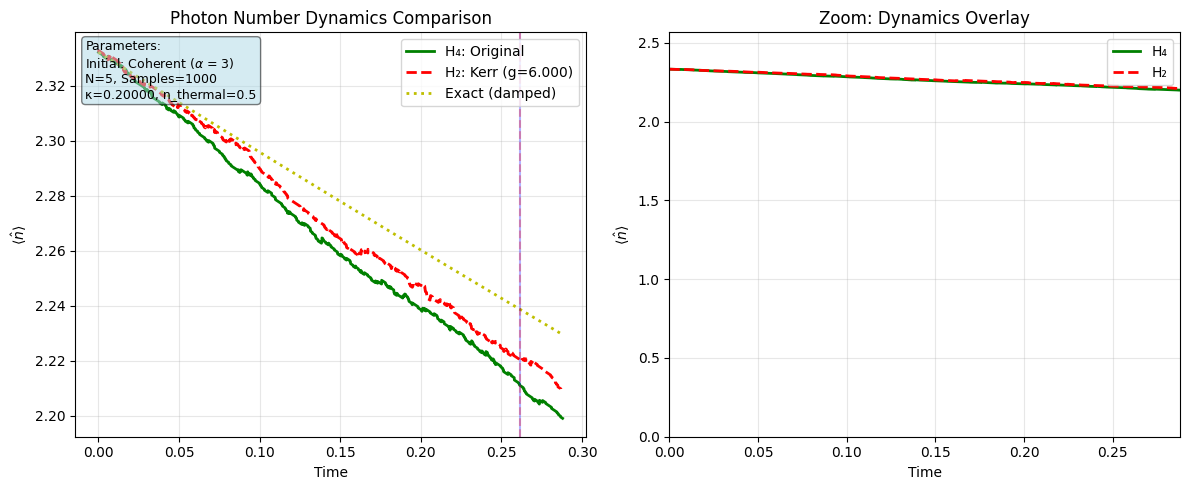

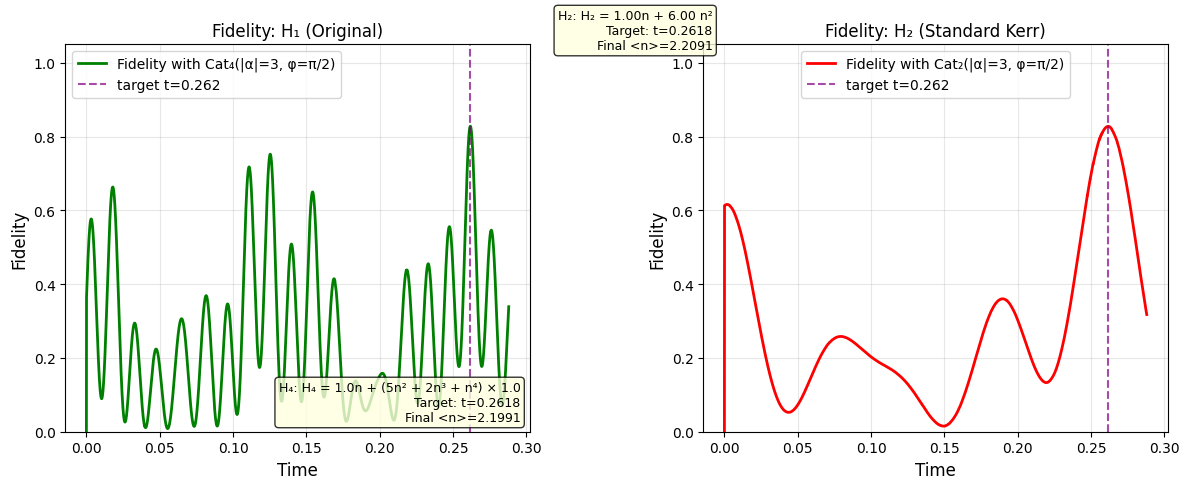

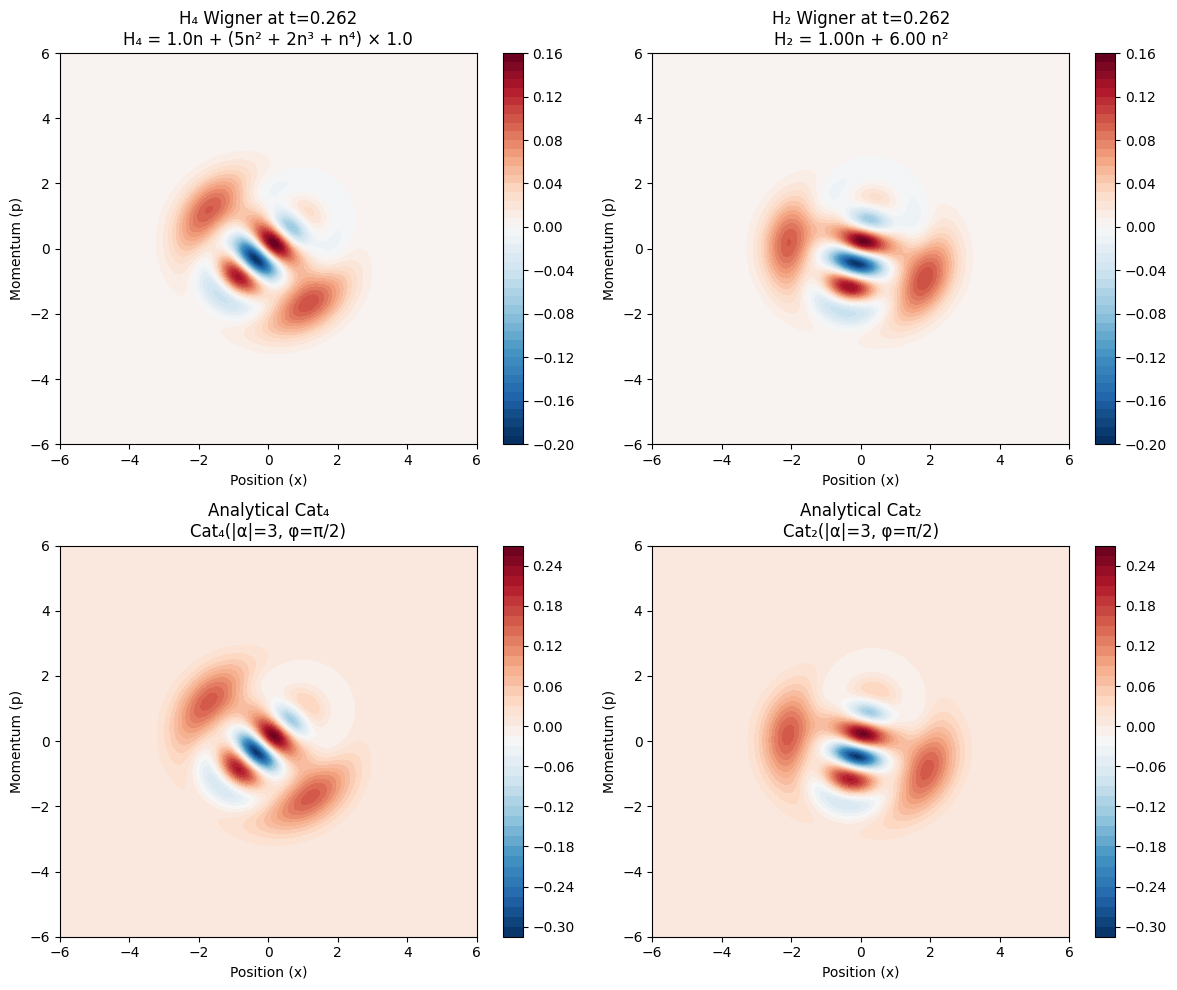

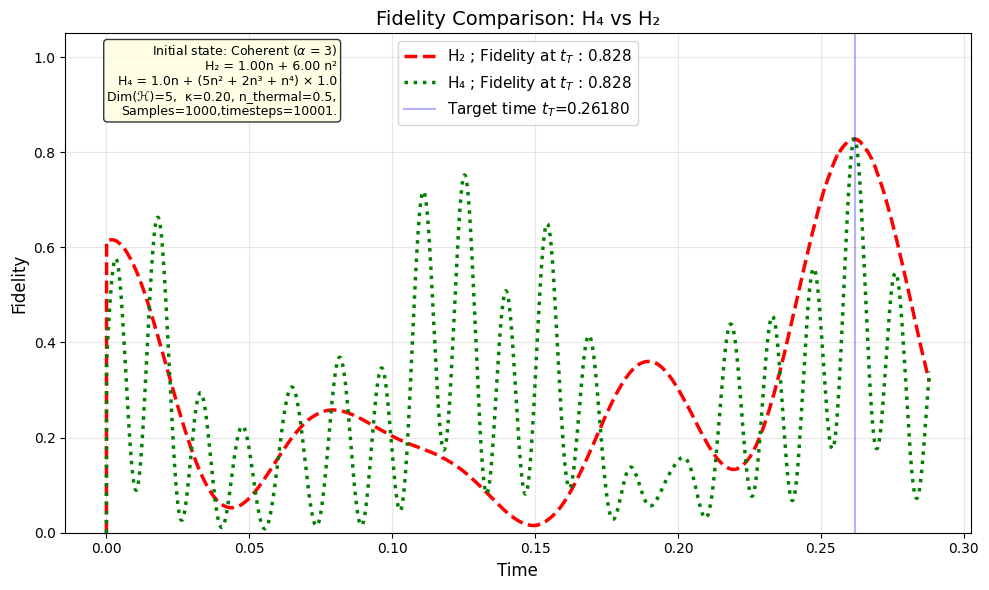

In [ ]:
# =============================================================================
# COMPARE DIFFERENT HAMILTONIANS 
# =============================================================================


import numpy as np
import matplotlib.pyplot as plt
import qutip as qt
import time  
import cmath 
from qutip import wigner
import matplotlib.colors as mcolors


def format_time(seconds):
    hours = int(seconds // 3600)
    minutes = int((seconds % 3600) // 60)
    secs = seconds % 60
    return f"{hours}h {minutes}m {secs:.1f}s"

def define_operators(N):
    a = qt.destroy(N)
    a_dag = qt.create(N)
    n = qt.num(N)
    x = qt.position(N)
    p = qt.momentum(N)
    return a, a_dag, n, x, p

def get_analytical_cat_state(t, N, Amplitude, omega, phase_cat):
    alpha_rotated = Amplitude * np.exp(-1j * omega * t)
    cat_unnorm = (qt.coherent(N, alpha_rotated) + 
                  np.exp(1j * phase_cat) * qt.coherent(N, -alpha_rotated))
    return cat_unnorm / cat_unnorm.norm()



def run_monte_carlo(H, Heff, psi0, tlist, dt_list, Ls, n, target_index, sample, 
                    cat_state, milestones, label=""):
    """Run Monte Carlo simulation for a given Hamiltonian"""
    mean_n = np.zeros(len(tlist), dtype=complex)
    fidelity_cat = np.zeros(len(tlist))
    state_at_target_time = None
    milestone_index = 0
    start_time = time.time()
    total_steps = sample * (len(tlist) - 1)
    current_step = 0
    dt = tlist[1] - tlist[0]
    evol_op = (-1.0j*Heff*dt).expm()
    print(f"\nStarting Monte Carlo simulation for {label}...")
    
    for count in range(sample):
        psi = psi0
        n_expect_list = [qt.expect(n, psi)]
        
        for i in range(1, len(tlist)):
            #dt = dt_list[i-1]
            u = np.random.random()

            dps = [np.real(dt * qt.expect(L.dag() * L, psi)) for L in Ls]
            dP = np.sum(dps)
            
            if dP < u:
                #evol_op = (-1.0j * Heff * dt).expm()
                psi = evol_op * psi
                norm_val = psi.norm()
                if norm_val > 0:
                    psi = psi / norm_val
                else:
                    print(f"Warning: Zero norm at step {i}, trajectory {count}")
                    break
            else:
                u_jump = np.random.random()
                Q = np.cumsum(dps) / dP
                k = np.searchsorted(Q, u_jump, side='left')
                psi = Ls[k] * psi
                norm_val = psi.norm()
                if norm_val > 0:
                    psi = psi / norm_val
            
            n_expect_list.append(qt.expect(n, psi))
            
            if i == target_index:
                if count == 0:
                    state_at_target_time = psi.copy()
                else:
                    state_at_target_time += psi
                    
            fidelity_this_traj = qt.fidelity(psi, cat_state)**2
            if count == 0:
                fidelity_cat[i] = fidelity_this_traj
            else:
                fidelity_cat[i] += fidelity_this_traj
            
            current_step += 1
            progress = (current_step / total_steps) * 100
            if milestone_index < len(milestones) and progress >= milestones[milestone_index]:
                elapsed_time = time.time() - start_time
                estimated_total_time = elapsed_time / (progress / 100)
                remaining_time = estimated_total_time - elapsed_time
                print(f"{label}: {milestones[milestone_index]:.3f}% completed, est. remaining: {format_time(remaining_time)}")
                milestone_index += 1
        
        while len(n_expect_list) < len(tlist):
            n_expect_list.append(n_expect_list[-1])
        mean_n += np.array(n_expect_list)
    
    mean_n /= sample
    fidelity_cat /= sample
    
    if state_at_target_time is not None:
        state_at_target_time /= sample
    
    total_time = time.time() - start_time
    print(f"{label} simulation completed in {format_time(total_time)}.")
    
    return mean_n, fidelity_cat, state_at_target_time, total_time


# ==================== USER INPUTS ====================
N = int(input("Enter the Hilbert space dimension N: "))

# Define operators
a, a_dag, n, x, p = define_operators(N)

# Lindblad operators (same for both)
kappa = 0.2
n_thermal = 0.5
Ls = [cmath.sqrt(kappa * (n_thermal + 1)) * a,
      cmath.sqrt(kappa * n_thermal) * a_dag]

# Initial state
Amplitude = 3
psi0 = qt.coherent(N, Amplitude)
initial_state_str = f"Coherent ($\\alpha$ = {Amplitude})"

# Time parameters
timesteps = 1 + 1*10**4 #number of time steps for simulation
K_4 = 1.0


# For H_4
w=1.0
final_time_1 = 1.1*2 * np.pi / (4 * 3 * 2 * K_4)
target_time_1 = 2 * np.pi / (4 * 3 * 2 * K_4)

# For H_2 (standard Kerr), choose g such that cat forms at comparable time
omega_kerr = 1.0
g_kerr = 6*K_4
final_time_2 = 1.1 * np.pi / (2 * g_kerr)  
target_time_2 = np.pi/(2*g_kerr)     

print(f"\n{'='*60}")
print(f"Hamiltonian 1 (multiple high-order terms): H4 = {w}n + (5n² + 2n³ + n⁴) × {K_4}")
print(f"  Target time: {target_time_1:.6f}")
print(f"\nHamiltonian 2 (Standard Kerr): H2 = ωn + g n²")
print(f"  g = {g_kerr:.6f}")
print(f"  Target time: {target_time_2:.6f}")
print(f"{'='*60}\n")

# Time lists
tlist_1 = np.linspace(0, final_time_1, timesteps)
dt_list_1 = np.diff(tlist_1)
tlist_2 = np.linspace(0, final_time_2, timesteps)
dt_list_2 = np.diff(tlist_2)

sample = 1000
milestones = [0.001, 0.01, 0.1, 1, 5, 10, 20, 50, 75, 90, 100]

# Target indices
target_index_1 = np.argmin(np.abs(tlist_1 - target_time_1))
target_index_2 = np.argmin(np.abs(tlist_2 - target_time_2))


# ==================== HAMILTONIAN_4: 4-TERMS H====================
H4 = w*n + (5*n**2 + 2*n**3 + n**4) * K_4 
Heff4 = H4 - 1j/2 * sum(L.dag() * L for L in Ls)
str_H4 = f"H₄ = {w}n + (5n² + 2n³ + n⁴) × {K_4}"

# Cat state for H4 (in rotating frame, omega=0)
cat_state_4 = get_analytical_cat_state(target_time_1, N, Amplitude, w+2*K_4, np.pi/2)
cat_state_str_4 = f"Cat₄(|α|={Amplitude}, φ=π/2)"

# Run simulation
mean_n_4, fidelity_cat_4, state_target_4, time_4 = run_monte_carlo(
    H4, Heff4, psi0, tlist_1, dt_list_1, Ls, n, target_index_1, sample,
    cat_state_4, milestones, "H4 (4-Term)"
)


# ==================== HAMILTONIAN_2: STANDARD KERR ====================
H2 = omega_kerr * n + g_kerr * n**2
Heff2 = H2 - 1j/2 * sum(L.dag() * L for L in Ls)
str_H2 = f"H₂ = {omega_kerr:.2f}n + {g_kerr:.2f} n²"

# Cat state for H2 (with linear rotation)
cat_state_2 = get_analytical_cat_state(target_time_2, N, Amplitude, omega_kerr, np.pi/2)
cat_state_str_2 = f"Cat₂(|α|={Amplitude}, φ=π/2)"

# Run simulation
mean_n_2, fidelity_cat_2, state_target_2, time_2 = run_monte_carlo(
    H2, Heff2, psi0, tlist_2, dt_list_2, Ls, n, target_index_2, sample,
    cat_state_2, milestones, "H2 (Kerr)"
)


# ==================== RESULTS & PLOTS ====================
index_1 = np.argmin(np.abs(tlist_1 - final_time_1))
index_2 = np.argmin(np.abs(tlist_2 - final_time_2))

print(f"\n{'='*60}")
print(f"RESULTS:")
print(f"H4: At t={tlist_1[index_1]:.6f}, <n>={np.real(mean_n_4[index_1]):.6f}")
print(f"H2: At t={tlist_2[index_2]:.6f}, <n>={np.real(mean_n_2[index_2]):.6f}")
print(f"{'='*60}")

# Exact solutions for comparison
n0 = np.real(qt.expect(n, psi0))
n_exact = n_thermal + (n0 - n_thermal) * np.exp(-np.real(kappa) * tlist_1)



# ----- PLOT 1: Dynamics Comparison -----
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(tlist_1, np.real(mean_n_4), '-g', linewidth=2, label=f"H₄: Original")
plt.plot(tlist_2, np.real(mean_n_2), '--r', linewidth=2, label=f"H₂: Kerr (g={g_kerr:.3f})")
plt.plot(tlist_1, n_exact, 'y:', linewidth=2, label="Exact (damped)")
plt.axvline(x=target_time_1, color='blue', alpha=0.3, linestyle='-')
plt.axvline(x=target_time_2, color='red', alpha=0.3, linestyle='--')
plt.xlabel(r'Time')
plt.ylabel(r'$\langle \hat{n} \rangle$')
plt.title('Photon Number Dynamics Comparison')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

# Parameter box
param_text = (f"Parameters:\n"
              f"Initial: {initial_state_str}\n"
              f"N={N}, Samples={sample}\n"
              f"κ={kappa.real:.5f}, n_thermal={n_thermal}")
plt.text(0.02, 0.98, param_text, transform=plt.gca().transAxes, fontsize=9,
         verticalalignment='top', bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.5))

plt.subplot(1, 2, 2)
plt.plot(tlist_1, np.real(mean_n_4), '-g', linewidth=2, label=f"H₄")
plt.plot(tlist_2, np.real(mean_n_2), '--r', linewidth=2, label=f"H₂")
plt.xlabel(r'Time')
plt.ylabel(r'$\langle \hat{n} \rangle$')
plt.title('Zoom: Dynamics Overlay')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.xlim(0, max(final_time_1, final_time_2))
plt.ylim(0, max(np.max(np.real(mean_n_4)), np.max(np.real(mean_n_2))) * 1.1)

plt.tight_layout()


# ----- PLOT 2: Fidelity Comparison -----
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(tlist_1, fidelity_cat_4, '-g', linewidth=2, label=f'Fidelity with {cat_state_str_4}')
plt.axvline(x=target_time_1, color='purple', linestyle='--', alpha=0.7, label=f'target t={target_time_1:.3f}')
plt.xlabel(r'Time', fontsize=12)
plt.ylabel(r'Fidelity', fontsize=12)
plt.title(f'Fidelity: H₁ (Original)', fontsize=12)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.05)

param_text_1 = (f"H₄: {str_H4}\n"
                f"Target: t={target_time_1:.4f}\n"
                f"Final <n>={np.real(mean_n_4[index_1]):.4f}")
plt.text(0.98, 0.02, param_text_1, transform=plt.gca().transAxes, fontsize=9,
         verticalalignment='bottom', horizontalalignment='right',
         bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.8))

plt.subplot(1, 2, 2)
plt.plot(tlist_2, fidelity_cat_2, '-r', linewidth=2, label=f'Fidelity with {cat_state_str_2}')
plt.axvline(x=target_time_2, color='purple', linestyle='--', alpha=0.7, label=f'target t={target_time_2:.3f}')
plt.xlabel(r'Time', fontsize=12)
plt.ylabel(r'Fidelity', fontsize=12)
plt.title(f'Fidelity: H₂ (Standard Kerr)', fontsize=12)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.05)

param_text_2 = (f"H₂: {str_H2}\n"
                f"Target: t={target_time_2:.4f}\n"
                f"Final <n>={np.real(mean_n_2[index_2]):.4f}")
plt.text(0.02, 0.98, param_text_2, transform=plt.gca().transAxes, fontsize=9,
         verticalalignment='bottom', horizontalalignment='right',
         bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.8))

plt.tight_layout()


# ----- PLOT 3: Wigner Functions Comparison -----
xvec = np.linspace(-6, 6, 200)
Pvec = np.linspace(-6, 6, 200)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# H4 Wigner
if state_target_4 is not None:
    W4 = wigner(state_target_4, xvec, Pvec)
    W4_int = np.trapezoid(np.trapezoid(W4, xvec), Pvec)
    print(f"\nH4 Wigner integral: {W4_int:.6f}")
    
    im1 = axes[0, 0].contourf(xvec, Pvec, W4, levels=50, cmap='RdBu_r',norm=mcolors.TwoSlopeNorm(vmin=W4.min(), vcenter=0, vmax=W4.max()))
    plt.colorbar(im1, ax=axes[0, 0])
    axes[0, 0].set_title(f'H₄ Wigner at t={target_time_1:.3f}\n{str_H4}')
    axes[0, 0].set_xlabel('Position (x)')
    axes[0, 0].set_ylabel('Momentum (p)')

# H2 Wigner
if state_target_2 is not None:
    W2 = wigner(state_target_2, xvec, Pvec)
    W2_int = np.trapezoid(np.trapezoid(W2, xvec), Pvec)
    print(f"H2 Wigner integral: {W2_int:.6f}")
    
    im2 = axes[0, 1].contourf(xvec, Pvec, W2, levels=50, cmap='RdBu_r',norm=mcolors.TwoSlopeNorm(vmin=W2.min(), vcenter=0, vmax=W2.max()))
    plt.colorbar(im2, ax=axes[0, 1])
    axes[0, 1].set_title(f'H₂ Wigner at t={target_time_2:.3f}\n{str_H2}')
    axes[0, 1].set_xlabel('Position (x)')
    axes[0, 1].set_ylabel('Momentum (p)')

# Analytical cat states Wigner
W_cat4 = wigner(cat_state_4, xvec, Pvec)
im3 = axes[1, 0].contourf(xvec, Pvec, W_cat4, levels=50, cmap='RdBu_r')
plt.colorbar(im3, ax=axes[1, 0])
axes[1, 0].set_title(f'Analytical Cat₄\n{cat_state_str_4}')
axes[1, 0].set_xlabel('Position (x)')
axes[1, 0].set_ylabel('Momentum (p)')

W_cat2 = wigner(cat_state_2, xvec, Pvec)
im4 = axes[1, 1].contourf(xvec, Pvec, W_cat2, levels=50, cmap='RdBu_r')
plt.colorbar(im4, ax=axes[1, 1])
axes[1, 1].set_title(f'Analytical Cat₂\n{cat_state_str_2}')
axes[1, 1].set_xlabel('Position (x)')
axes[1, 1].set_ylabel('Momentum (p)')

plt.tight_layout()


# ----- PLOT 4: Direct Fidelity Overlay -----
plt.figure(figsize=(10, 6))
plt.plot(tlist_2, fidelity_cat_2, '--r', linewidth=2.5, label=f'H₂ ; Fidelity at $t_T$ : {fidelity_cat_2[target_index_2]:.3f}')
plt.plot(tlist_1, fidelity_cat_4, ':g', linewidth=2.5, label=f'H₄ ; Fidelity at $t_T$ : {fidelity_cat_4[target_index_1]:.3f}')
plt.axvline(x=target_time_1, color='blue', alpha=0.3, linestyle='-', label=f'Target time $t_T$={target_time_1:.5f}')
#plt.axvline(x=target_time_2, color='red', alpha=0.3, linestyle='--') #commented for clarity, since target times are the same
plt.xlabel(r'Time', fontsize=12)
plt.ylabel(r'Fidelity', fontsize=12)
plt.title('Fidelity Comparison: H₄ vs H₂', fontsize=14)
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.05)

param_text_comp = (
                   f"Initial state: {initial_state_str}\n"
                   f"{str_H2}\n"
                   f"{str_H4}\n"
                   f"Dim(ℋ)={N},  κ={kappa.real:.2f}, n_thermal={n_thermal},\n"
                   f"Samples={sample},timesteps={timesteps}.")

plt.text(0.3, 0.83, param_text_comp, transform=plt.gca().transAxes, fontsize=9,
         verticalalignment='bottom', horizontalalignment='right',
         bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.8))

plt.tight_layout()
plt.show()